<a href="https://colab.research.google.com/github/iighnaya-ui/Libyan-Sentiment-Analysis/blob/main/TCATWEET2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip show scikit-learn

Name: scikit-learn
Version: 1.6.1
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License: BSD 3-Clause License

 Copyright (c) 2007-2024 The scikit-learn developers.
 All rights reserved.

 Redistribution and use in source and binary forms, with or without
 modification, are permitted provided that the following conditions are met:

 * Redistributions of source code must retain the above copyright notice, this
   list of conditions and the following disclaimer.

 * Redistributions in binary form must reproduce the above copyright notice,
   this list of conditions and the following disclaimer in the documentation
   and/or other materials provided with the distribution.

 * Neither the name of the copyright holder nor the names of its
   contributors may be used to endorse or promote products derived from
   this software without specific prior written permission.

 THIS SOFTWARE IS PROVIDED BY THE COPYR

# New Section

In [2]:
!pip install --upgrade scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 63.1 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
#from sklearn.metrics import plot_confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC

In [10]:
columns = ['ID','tweet_text', 'Sentiment']
data = pd.read_excel('/content/libyan_lexicon.xlsx', names=columns)
data.head()

,ID,tweet_text,Sentiment
0,1,خدمات الجيل الرابع موفقين,Positive
1,2,ياريت تحسنو سرعه النت بس,Negative
2,3,كل الخدمات راىعه بجد ربنا يوفقكم,Positive
3,4,ردو عليا عندي مشكله في نت,Negative
4,5,نبى نفهم كيف الواحد بعبى رصيد ومزال ميتفعلش ال...,Negative


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   ID          3600 non-null   object
 1   tweet_text  3600 non-null   object
 2   Sentiment   3600 non-null   object
dtypes: object(3)
memory usage: 84.5+ KB


In [12]:
data.describe().transpose()

,count,unique,top,freq
ID,3600,3599,1800,2
tweet_text,3600,3534,بالتوفيق,7
Sentiment,3600,2,Positive,1800


In [13]:
data.sample(8)

,ID,tweet_text,Sentiment
2442,2442,يجب معالجه تقطع النت من وقت الى اخر,Negative
1263,1264,التحديث الاخير اصبح يعطل في الدخول و يعطل هلبا,Negative
2790,2790,بعدك اشتراك اليوم يكمل,Positive
1108,1109,تعاملكم هو رمز الاحترام لكل كل الاحترام,Positive
764,765,موفقين ان شاء الله تحيه تقدير واحترام,Positive
3493,3493,عرض العيد وينه,Positive
3225,3225,نتامل فيكم كل خير والله,Positive
2675,2675,مازال اسعاركم غاليه,Negative


In [14]:
data.tail(8)

,ID,tweet_text,Sentiment
3592,3592,شرط النسيب الكاره مانببش نشترك في عروضكم,Negative
3593,3593,عرض كمين لا احد يشترك فيه,Negative
3594,3594,لم نستفيد منها العرض هوا,Negative
3595,3595,مباش يتفعل تجرو ب ناس ولا كيف,Negative
3596,3596,نحب نبلغ عن مشكله صارتلي مع خدمه العملاء,Negative
3597,3597,مشتركه في مزاجي,Positive
3598,3598,واريد كوبون شاهد,Positive
3599,3599,ماشاءالله موفقين,Positive


In [15]:
len(data)

3600

In [16]:
data['Sentiment'].head()

,Sentiment
0,Positive
1,Negative
2,Positive
3,Negative
4,Negative


In [17]:
np.sum(data.isnull().any(axis=1))

np.int64(0)

In [18]:
data.isnull().any(axis=0)

,0
ID,False
tweet_text,False
Sentiment,False


In [19]:
data.value_counts('Sentiment')

,count
Sentiment,
Negative,1800
Positive,1800


<Axes: xlabel='Sentiment', ylabel='count'>

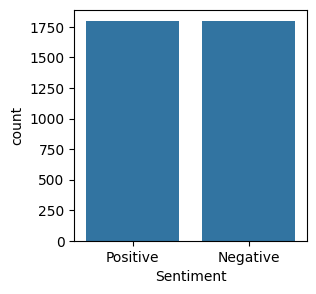

In [20]:
fig = plt.figure(figsize=(3, 3), dpi=100)
sns.countplot(data=data, x='Sentiment')

In [21]:
# splitting the data into target and features
features = data.tweet_text
target = data.Sentiment
# splitting into train and tests
X_train, X_test, Y_train, Y_test = train_test_split(features, target, test_size =.2, random_state=100, shuffle=True)

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1

In [23]:
# make pipeline
pipe = make_pipeline(TfidfVectorizer(), LogisticRegression())

In [24]:
# make param grid
param_grid = {'logisticregression__C': [0.01, 0.1, 1, 10, 100]}

In [25]:
# create and fit the model or train your model
model = GridSearchCV(pipe, param_grid, cv=5)
model.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'logisticregression__C': [0.01, 0.1, ...]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during 

Accuracy score is 0.80
              precision    recall  f1-score   support

    Negative       0.79      0.80      0.79       343
    Positive       0.81      0.81      0.81       377

    accuracy                           0.80       720
   macro avg       0.80      0.80      0.80       720
weighted avg       0.80      0.80      0.80       720

[[273  70]
 [ 71 306]]
16      Negative
3479    Negative
2820    Negative
3090    Positive
3288    Negative
8       Positive
2504    Negative
3190    Negative
3115    Negative
1273    Positive
Name: Sentiment, dtype: object
['Negative' 'Positive' 'Negative' 'Negative' 'Negative' 'Positive'
 'Positive' 'Negative' 'Negative' 'Positive']
['Positive']


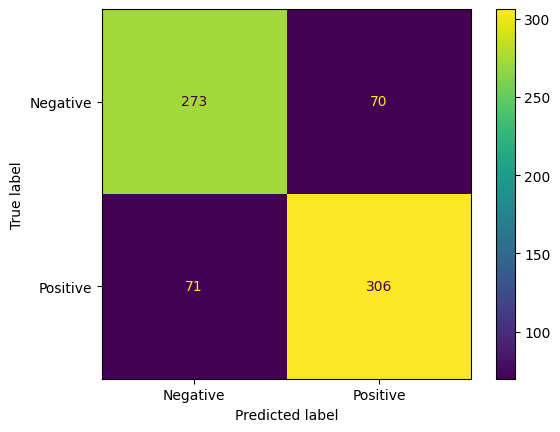

In [26]:
# make prediction and print accuracy
prediction = model.predict(X_test)
print(f"Accuracy score is {accuracy_score(Y_test, prediction):.2f}")
print(classification_report(Y_test, prediction))
print(confusion_matrix(Y_test, prediction))
cm = confusion_matrix(Y_test, prediction, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=model.classes_)
disp.plot()
#plot_confusion_matrix(model, X_test, prediction, normalize='all')
print(Y_test[:10])
print(prediction[:10])
prediction = model.predict(['التطبيق يعمل وممتاز عندي بالاصدار السابق'])
print(prediction)

2

In [27]:
# make pipeline
pipe = make_pipeline(TfidfVectorizer(), RandomForestClassifier())

In [28]:
# make param grid
param_grid = {'randomforestclassifier__n_estimators':[10, 100, 1000],
             'randomforestclassifier__max_features':['sqrt', 'log2']}

In [29]:
# create and fit and train the model
rf_model = GridSearchCV(pipe, param_grid, cv=5)
rf_model.fit(X_train,Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'randomforestclassifier__max_features': ['sqrt', 'log2'], 'randomforestclassifier__n_estimators': [10, 100, ...]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbo

Accuracy score is 0.80
              precision    recall  f1-score   support

    Negative       0.83      0.73      0.78       343
    Positive       0.78      0.86      0.82       377

    accuracy                           0.80       720
   macro avg       0.80      0.80      0.80       720
weighted avg       0.80      0.80      0.80       720

[[252  91]
 [ 53 324]]
16      Negative
3479    Negative
2820    Negative
3090    Positive
3288    Negative
8       Positive
2504    Negative
3190    Negative
3115    Negative
1273    Positive
Name: Sentiment, dtype: object
['Negative' 'Positive' 'Positive' 'Negative' 'Negative' 'Positive'
 'Positive' 'Negative' 'Positive' 'Positive']
##################################################
['Positive']


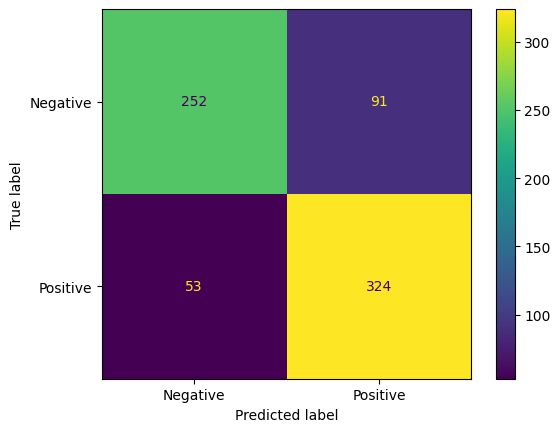

In [30]:
# make prediction and print accuracy
prediction = rf_model.predict(X_test)
print(f"Accuracy score is {accuracy_score(Y_test, prediction):.2f}")
print(classification_report(Y_test, prediction))
print(confusion_matrix(Y_test, prediction))
#plot_confusion_matrix(rf_model, X_test, prediction, normalize='true')
cm = confusion_matrix(Y_test, prediction, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=model.classes_)
disp.plot()
print(Y_test[:10])
print(prediction[:10])
print('#'*50)
prediction = model.predict(['تم التحديث بالتوفيق والنجاح ان شاء الله'])
print(prediction)

3

In [31]:
# make pipeline
pipe = make_pipeline(TfidfVectorizer(), SVC())

In [32]:
# make param grid
param_grid = {'svc__kernel': ['rbf', 'linear', 'poly'],
             'svc__gamma': [0.1, 1, 10, 100],
             'svc__C': [0.1, 1, 10, 100]}

In [33]:
# create and fit the model
svc_model = GridSearchCV(pipe, param_grid, cv=3)
svc_model.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...svc', SVC())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'svc__C': [0.1, 1, ...], 'svc__gamma': [0.1, 1, ...], 'svc__kernel': ['rbf', 'linear', ...]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0C

Accuracy score is 0.81
              precision    recall  f1-score   support

    Negative       0.79      0.81      0.80       343
    Positive       0.82      0.80      0.81       377

    accuracy                           0.81       720
   macro avg       0.81      0.81      0.81       720
weighted avg       0.81      0.81      0.81       720

[[279  64]
 [ 76 301]]
16      Negative
3479    Negative
2820    Negative
3090    Positive
3288    Negative
8       Positive
2504    Negative
3190    Negative
3115    Negative
1273    Positive
Name: Sentiment, dtype: object
['Negative' 'Negative' 'Negative' 'Negative' 'Negative' 'Positive'
 'Positive' 'Negative' 'Negative' 'Positive']
--------------------------------------------------
['Positive']


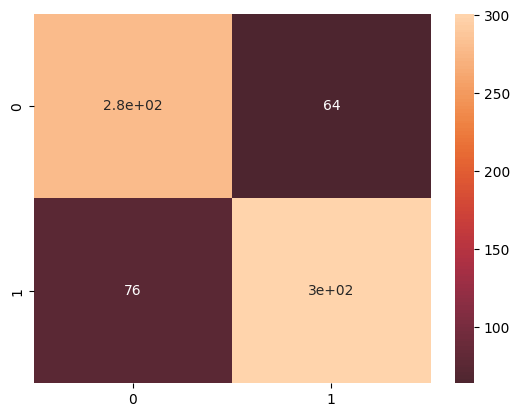

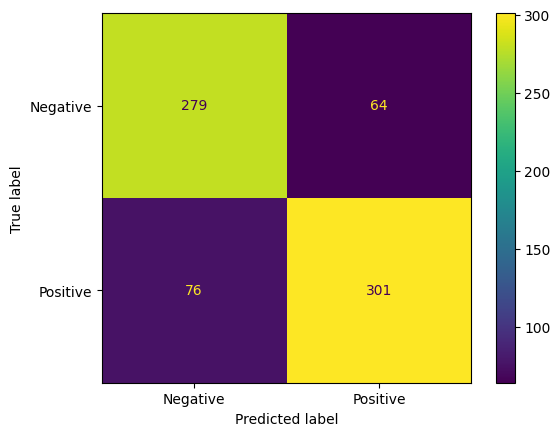

In [34]:
# make prediction and print accuracy
prediction = svc_model.predict(X_test)
print(f"Accuracy score is {accuracy_score(Y_test, prediction):.2f}")
print(classification_report(Y_test, prediction))
print(confusion_matrix(Y_test, prediction))
sns.heatmap(confusion_matrix(Y_test, prediction), center=True, annot=True)
#plot_confusion_matrix(svc_model, X_test, prediction)
cm = confusion_matrix(Y_test, prediction, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=model.classes_)
disp.plot()
print(Y_test[:10])
print(prediction[:10])
print('-' * 50)
prediction = model.predict(['ما شاء الله خدمة العملاء ممتازة والاستجابة سريعة وموسعين بالهم بارك الله في مهندسينكم'])
print(prediction)

4

In [35]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.naive_bayes import MultinomialNB, BernoulliNB

In [36]:
# splitting the data into target and features
features = data.tweet_text
target = data.Sentiment
# splitting into train and tests
X_train, X_test, Y_train, Y_test = train_test_split(features, target, test_size =.2, random_state=100, shuffle=True)

In [37]:
# make pipeline
pipe = Pipeline([('tfidf', TfidfVectorizer()),
                     ('clf', MultinomialNB())])

In [38]:
# make param grid
param_grid = {
    'clf__alpha': [1, 1e-1, 1e-2],
    'tfidf__use_idf': (True, False)
}

In [39]:
# create and fit the model
from sklearn.metrics import classification_report
MultinomialNB_model = GridSearchCV(pipe, param_grid)
MultinomialNB_model.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...inomialNB())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__alpha': [1, 0.1, ...], 'tfidf__use_idf': (True, ...)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: int, default=0Controls the verbosity of informa

Accuracy score is 0.82
              precision    recall  f1-score   support

    Negative     0.7798    0.8571    0.8167       343
    Positive     0.8571    0.7798    0.8167       377

    accuracy                         0.8167       720
   macro avg     0.8185    0.8185    0.8167       720
weighted avg     0.8203    0.8167    0.8167       720

*******************************************************
              precision    recall  f1-score   support

    Negative       0.78      0.86      0.82       343
    Positive       0.86      0.78      0.82       377

    accuracy                           0.82       720
   macro avg       0.82      0.82      0.82       720
weighted avg       0.82      0.82      0.82       720

[[294  49]
 [ 83 294]]
16      Negative
3479    Negative
2820    Negative
3090    Positive
3288    Negative
8       Positive
2504    Negative
3190    Negative
3115    Negative
1273    Positive
Name: Sentiment, dtype: object
['Negative' 'Negative' 'Negative' 'Negative

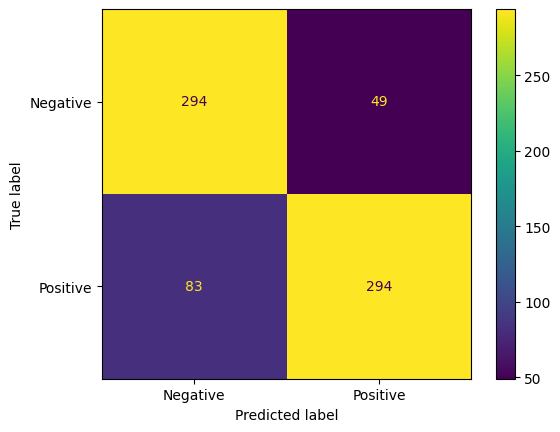

In [40]:
# make prediction and print accuracy
prediction = MultinomialNB_model.predict(X_test)
print(f"Accuracy score is {accuracy_score(Y_test, prediction):.2f}")
print(classification_report(Y_test, MultinomialNB_model.predict(X_test), digits=4))
print('*' * 55)
print(classification_report(Y_test, prediction))
print(confusion_matrix(Y_test, prediction))
#plot_confusion_matrix(MultinomialNB_model, X_test, prediction, normalize='all')
cm = confusion_matrix(Y_test, prediction, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=model.classes_)
disp.plot()
print(Y_test[:10])
print(prediction[:10])
print('*' * 65)
prediction = MultinomialNB_model.predict(['تحزن فان الله يدافع عنك و الملائكة تستغفر لك'])
print(prediction)